# Voronoiness versus noise

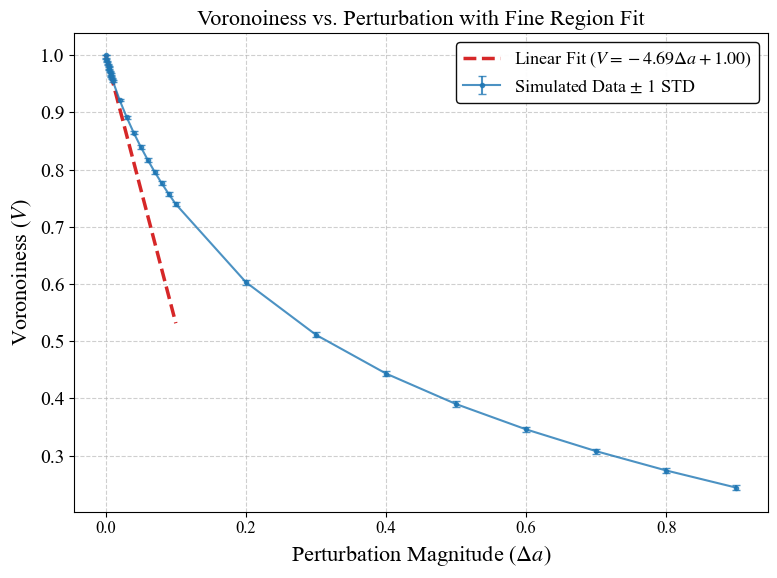

Fitted Slope: -4.6852
Forced Intercept: 1.0000


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1) Setup & Publication Styling
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'stix', 
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'figure.titlesize': 18
})

# ==========================================
# 2) Data Definition
# ==========================================
a = np.array([
    0.000, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01,
    0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1,
    0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9
])

v = np.array([
    1.0000, 0.9939, 0.9888, 0.9840, 0.9795, 0.9751, 0.9709, 0.9668, 0.9629, 0.9590, 0.9552,
    0.9210, 0.8911, 0.8642, 0.8396, 0.8168, 0.7956, 0.7758, 0.7571, 0.7395,
    0.6032, 0.5112, 0.4435, 0.3902, 0.3459, 0.3078, 0.2741, 0.2441
])

v_std = np.array([
    0.0000, 0.0006, 0.0008, 0.0009, 0.0010, 0.0012, 0.0012, 0.0013, 0.0014, 0.0015, 0.0016,
    0.0021, 0.0024, 0.0027, 0.0029, 0.0031, 0.0033, 0.0034, 0.0035, 0.0036,
    0.0042, 0.0044, 0.0045, 0.0045, 0.0044, 0.0043, 0.0042, 0.0040
])

# ==========================================
# 3) Isolate Fine Data and Fit (Forced Intercept = 1)
# ==========================================
# Filter for the fine region (a <= 0.01)
mask_fine = a <= 0.01
a_fine = a[mask_fine]
v_fine = v[mask_fine]

# Perform linear fit with forced intercept of 1: v = slope * a + 1
# This is equivalent to solving (v - 1) = slope * a
x = a_fine[:, np.newaxis]
y = v_fine - 1.0

# Calculate the optimal slope using least squares
slope = np.linalg.lstsq(x, y, rcond=None)[0][0]
intercept = 1.0

# Generate points for the fit line (extending slightly for visibility)
a_fit_line = np.linspace(0, 0.1, 100)
v_fit_line = slope * a_fit_line + intercept

# Format the equation for the legend
fit_eq = fr"Linear Fit ($V = {slope:.2f}\Delta a + {intercept:.2f}$)"

# ==========================================
# 4) Plotting
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

# Plot original data with error bars
ax.errorbar(
    a, v, yerr=v_std, fmt='o-', color='tab:blue', ecolor='tab:blue',
    markersize=3, capsize=3, elinewidth=1.5, alpha=0.8, label=r"Simulated Data $\pm$ 1 STD"
)

# Plot fit line overlay
ax.plot(a_fit_line, v_fit_line, '--', color='tab:red', linewidth=2.5, label=fit_eq)

# Formatting
ax.set_xlabel(r'Perturbation Magnitude ($\Delta a$)')
ax.set_ylabel(r'Voronoiness ($V$)')
ax.set_title(r'Voronoiness vs. Perturbation with Fine Region Fit')

ax.grid(True, which="both", linestyle='--', alpha=0.6)
ax.legend(loc='upper right', framealpha=0.95, edgecolor='black')

plt.tight_layout()
plt.savefig('voronoiness_fit_with_error_forced_intercept.png', dpi=300)
plt.show()

# Print the fitted values to the console
print(f"Fitted Slope: {slope:.4f}")
print(f"Forced Intercept: {intercept:.4f}")